In [253]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors

In [308]:
colormap = cm.get_cmap("seismic")

# Create colormap of two white colors, one with alpha=0 and other one with alpha=1
c = [(0, 0, 0, 0), (0, 0, 0, 0), (0, 0, 0, 1)]
# Create new colormap from our two colors
cmap = colors.LinearSegmentedColormap.from_list('mycmap', c)

/var/folders/9d/91392f990_s6q5jtqnwhg2s00000gn/T/ipykernel_2243/3729549100.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap("seismic")


In [319]:
def plot_grid(
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
    n_lines: int,
    line_points: int,
    map_func,
    **kwargs,
):
    """
    Plot a transformation of a regular grid.

    :param xmin: Minimum x value
    :param xmax: Maximum x value
    :param ymin: Minimum y value
    :param ymax: Maximum y value
    :param n_lines: Number of lines per axis
    :param line_points: Number of points per line
    :param map_func: Function to map the grid points to new coordinates
    """
    # List for gathering the lines into.
    lines = []

    # Iterate over horizontal lines.
    for y in np.linspace(ymin, ymax, n_lines):
        lines.append([map_func(x, y) for x in np.linspace(xmin, xmax, line_points)])

    # Iterate over vertical lines.
    for x in np.linspace(xmin, xmax, n_lines):
        lines.append([map_func(x, y) for y in np.linspace(ymin, ymax, line_points)])

    # Plot all the lines.
    for i, line in enumerate(lines):
        p = i / (len(lines) - 1)  # Normalize to 0-1.
        # Transpose the list of points for passing to plot.
        xs, ys = zip(*line)
        # Get the line color from the colormap.
        plt.plot(xs, ys, color='black', alpha=0.2, **kwargs)

In [320]:
def sct(x, y): 
	z = complex(x, y)
	res = 1/z
	return (res.real, res.imag)

def iden(x, y): 
	return (x, y)

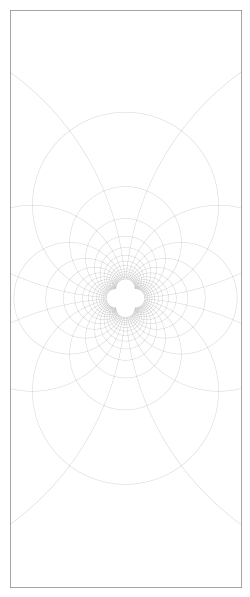

In [321]:
aspect = 2.5
max = 20
min = -max
nlines = 30
xlim = 0.3
fig, ax = plt.subplots(figsize=(3, 3*aspect))

plot_grid(min, max, min, max, nlines, 1000, sct, linewidth=0.3)
# plot_grid(min, max, min, max, nlines, 1000, iden, linewidth=0.3)



ax.tick_params(length=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.axis('square')
ax.set_xlim(-xlim, xlim)
ax.set_ylim(-aspect* xlim, aspect*xlim)
# disable grid 
plt.grid()
plt.savefig('../2024/figs/sct.pdf')